In [20]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**GENERAL PROCEDURE**

-1) This runs at the leica-env<br />
0) Use the loader2 function to extract images from Leica file system
1) Launch napari (in a different terminal start micro-sam conda env (conda activate micro-sam) and there launch napari (just type napari, then Enter)).
2) Load images in Napari: File, Load Files as Stack...
3) Find the frames where the Antennal Lobes (AL) are visible before .
4) Make masks out of these selected frames by:
    a)

In [24]:
loader2('2025_11_29','Gerardo',True)

Darwin
/Users/gerard/data/confocal/2025_11_29_Gerardo
Number of series: 12
series 0: shape = (1, 3, 101, 512, 512)
series 1: shape = (1, 3, 103, 512, 512)
series 2: shape = (1, 3, 101, 512, 512)
series 3: shape = (1, 3, 58, 512, 512)
series 4: shape = (1, 3, 44, 512, 512)
series 5: shape = (1, 3, 46, 512, 512)
series 6: shape = (1, 3, 48, 512, 512)
series 7: shape = (1, 3, 43, 512, 512)
series 8: shape = (1, 3, 52, 512, 512)
series 9: shape = (1, 3, 25, 512, 512)
series 10: shape = (1, 3, 57, 512, 512)
series 11: shape = (1, 3, 52, 512, 512)


**WHAT IS EACH SERIES OBTAINED PREVIOUSLY**<br />
numbers correspond to notebooks's map:<br />
**--5X training**<br />
series_0: brain 1, ALL<br />
series_1: brain 2, ALL<br />
series_2: brain 3, ALL<br /><br />


series_3: brain 3, MB<br />
series_4: brain 2, MB<br />
series_5: brain 1, MB<br />
series_6: brain 4, MB<br />
series_7: brain 5, MB<br /><br />

**--1X training**<br />
series_8: brain 6, MB<br />
series_9: brain 7, MB<br />
series_10: brain 8, MB<br />
series_11: brain 9, MB<br />


**Frames used as mask for the Antennal Lobe (AL), MB alpha lobe (MBa)**<br />
series_5: brain 1 MB: <br />
-AL: [0,7]<br />
-MBa : [14,41] <br />

series_3: brain 3 MB: <br />
-AL: [0,8]<br />
-MBa : [14,37] <br />

series_8: brain 6, MB:<br />
-AL: [0,8]<br />
-MBa : [16,40] <br />



In [6]:
def basic_ratios(series_n):
    
    series = 'series_' + str(series_n)
    s = 's' + str(series_n)
    
    results = {}
    results['brp'] = {}
    results['mito'] = {}
    results['hsp'] = {}
    
    msk_AL = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_AL.tif'
    msk_MBa = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_MBa.tif'
    
    
    al = signal_extractor(msk_AL, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_AL.tif')
    brp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_MBa.tif')
    mito = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch1_MBa.tif')
    hsp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch2_MBa.tif')
    
    denominatorL1 = brp['0']['1']
    denominatorL2 = brp['0']['2']
    denominatorL3 = brp['0']['3']
    
    denominatorR1 = brp['0']['4']
    denominatorR2 = brp['0']['5']
    denominatorR3 = brp['0']['6']
    
    results['brp']['a1'] = brp['0']['1'] / denominatorL1, brp['0']['4'] / denominatorR1
    results['brp']['a2'] = brp['0']['2'] / denominatorL2, brp['0']['5'] / denominatorR2
    results['brp']['a3'] = brp['0']['3'] / denominatorL3, brp['0']['6'] / denominatorR3

    results['mito']['a1'] = mito['0']['1'] / denominatorL1, mito['0']['4'] / denominatorR1
    results['mito']['a2'] = mito['0']['2'] / denominatorL2, mito['0']['5'] / denominatorR2
    results['mito']['a3'] = mito['0']['3'] / denominatorL3, mito['0']['6'] / denominatorR3
 
    
    results['hsp']['a1'] = hsp['0']['1'] / denominatorL1, hsp['0']['4'] / denominatorR1
    results['hsp']['a2'] = hsp['0']['2'] / denominatorL2, hsp['0']['5'] / denominatorR2
    results['hsp']['a3'] = hsp['0']['3'] / denominatorL3, hsp['0']['6'] / denominatorR3
    

    
    
    return results




In [7]:

def raw_values(series_n):
    
    series = 'series_' + str(series_n)
    s = 's' + str(series_n)
    
    results = {}
    results['brp'] = {}
    results['mito'] = {}
    results['hsp'] = {}
    
    msk_AL = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_AL.tif'
    msk_MBa = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_MBa.tif'
    
    
    al = signal_extractor(msk_AL, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_AL.tif')
    brp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_MBa.tif')
    mito = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch1_MBa.tif')
    hsp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch2_MBa.tif')
    
    
    results['brp']['a1'] = brp['0']['1'], brp['0']['4']
    results['brp']['a2'] = brp['0']['2'], brp['0']['5'] 
    results['brp']['a3'] = brp['0']['3'], brp['0']['6']

    results['mito']['a1'] = mito['0']['1'], mito['0']['4']
    results['mito']['a2'] = mito['0']['2'], mito['0']['5']
    results['mito']['a3'] = mito['0']['3'], mito['0']['6']
 
    
    results['hsp']['a1'] = hsp['0']['1'], hsp['0']['4']
    results['hsp']['a2'] = hsp['0']['2'], hsp['0']['5']
    results['hsp']['a3'] = hsp['0']['3'], hsp['0']['6']
    
    
    results['al'] =  al['0']['1'], al['0']['2']
    

    
    
    return results




In [8]:
##### 5x
br1 = basic_ratios(5)
print(f"brp: {br1['brp']}")
print(f"mito: {br1['mito']}")
print(f"hsp: {br1['hsp']}")

br2 = basic_ratios(4)
br3 = basic_ratios(3)
br4 = basic_ratios(6)
br5 = basic_ratios(7)
##### 1x
br6 = basic_ratios(8)
br7 = basic_ratios(9)
br8 = basic_ratios(10)
br9 = basic_ratios(11)



brp: {'a1': (1.0, 1.0), 'a2': (1.0, 1.0), 'a3': (1.0, 1.0)}
mito: {'a1': (1.5750350631136045, 1.6305818673883627), 'a2': (1.4252958579881656, 1.4527472527472527), 'a3': (0.9316381825760732, 1.0936507936507938)}
hsp: {'a1': (6.711781206171109, 6.622462787550744), 'a2': (7.103550295857988, 7.216483516483517), 'a3': (7.704877032096706, 7.242857142857144)}


In [10]:
# RAW
##### 5x
brr1 = raw_values(5)
brr2 = raw_values(4)
brr3 = raw_values(3)
brr4 = raw_values(6)
brr5 = raw_values(7)
##### 1x
brr6 = raw_values(8)
brr7 = raw_values(9)
brr8 = raw_values(10)
brr9 = raw_values(11)





In [11]:
print(brr1)

{'brp': {'a1': (8.9125, 7.038095238095238), 'a2': (8.144578313253012, 6.791044776119403), 'a3': (10.252136752136753, 9.197080291970803)}, 'mito': {'a1': (14.0375, 11.476190476190476), 'a2': (11.608433734939759, 9.865671641791044), 'a3': (9.551282051282051, 10.058394160583942)}, 'hsp': {'a1': (59.81875, 46.60952380952381), 'a2': (57.855421686746986, 49.007462686567166), 'a3': (78.99145299145299, 66.61313868613139)}, 'al': (6.193110140708394, 6.904864532019705)}


In [10]:
# POOLING ALL VALUES
## 5x
brp_a1_5x_all = list(br1['brp']['a1']+ br2['brp']['a1']+ br3['brp']['a1']+ br4['brp']['a1'] + br5['brp']['a1'])
brp_a2_5x_all = list(br1['brp']['a2']+ br2['brp']['a2']+ br3['brp']['a2']+ br4['brp']['a2'] + br5['brp']['a2'])
brp_a3_5x_all = list(br1['brp']['a3']+ br2['brp']['a3']+ br3['brp']['a3']+ br4['brp']['a3'] + br5['brp']['a3'])

hsp_a1_5x_all = list(br1['hsp']['a1']+ br2['hsp']['a1']+ br3['hsp']['a1']+ br4['hsp']['a1'] + br5['hsp']['a1'])
hsp_a2_5x_all = list(br1['hsp']['a2']+ br2['hsp']['a2']+ br3['hsp']['a2']+ br4['hsp']['a2'] + br5['hsp']['a2'])
hsp_a3_5x_all = list(br1['hsp']['a3']+ br2['hsp']['a3']+ br3['hsp']['a3']+ br4['hsp']['a3'] + br5['hsp']['a3'])

mito_a1_5x_all = list(br1['mito']['a1']+ br2['mito']['a1']+ br3['mito']['a1']+ br4['mito']['a1'] + br5['mito']['a1'])
mito_a2_5x_all = list(br1['mito']['a2']+ br2['mito']['a2']+ br3['mito']['a2']+ br4['mito']['a2'] + br5['mito']['a2'])
mito_a3_5x_all = list(br1['mito']['a3']+ br2['mito']['a3']+ br3['mito']['a3']+ br4['mito']['a3'] + br5['mito']['a3'])


## 1x
brp_a1_1x_all = list(br6['brp']['a1']+ br7['brp']['a1']+ br8['brp']['a1']+ br9['brp']['a1'])
brp_a2_1x_all = list(br6['brp']['a2']+ br7['brp']['a2']+ br8['brp']['a2']+ br9['brp']['a2'])
brp_a3_1x_all = list(br6['brp']['a3']+ br7['brp']['a3']+ br8['brp']['a3']+ br9['brp']['a3'])

hsp_a1_1x_all = list(br6['hsp']['a1']+ br7['hsp']['a1']+ br8['hsp']['a1']+ br9['hsp']['a1'])
hsp_a2_1x_all = list(br6['hsp']['a2']+ br7['hsp']['a2']+ br8['hsp']['a2']+ br9['hsp']['a2'])
hsp_a3_1x_all = list(br6['hsp']['a3']+ br7['hsp']['a3']+ br8['hsp']['a3']+ br9['hsp']['a3'])

mito_a1_1x_all = list(br6['mito']['a1']+ br7['mito']['a1']+ br8['mito']['a1']+ br9['mito']['a1'])
mito_a2_1x_all = list(br6['mito']['a2']+ br7['mito']['a2']+ br8['mito']['a2']+ br9['mito']['a2'])
mito_a3_1x_all = list(br6['mito']['a3']+ br7['mito']['a3']+ br8['mito']['a3']+ br9['mito']['a3'])

# RAW VALUES

# ## 5x
# brp_a1_5x_all_r = list(brr1['brp']['a1']+ brr2['brp']['a1']+ brr3['brp']['a1']+ brr4['brp']['a1'] + brr5['brp']['a1'])
# brp_a2_5x_all_r = list(brr1['brp']['a2']+ brr2['brp']['a2']+ brr3['brp']['a2']+ brr4['brp']['a2'] + brr5['brp']['a2'])
# brp_a3_5x_all_r = list(brr1['brp']['a3']+ brr2['brp']['a3']+ brr3['brp']['a3']+ brr4['brp']['a3'] + brr5['brp']['a3'])

# hsp_a1_5x_all_r = list(brr1['hsp']['a1']+ brr2['hsp']['a1']+ brr3['hsp']['a1']+ brr4['hsp']['a1'] + brr5['hsp']['a1'])
# hsp_a2_5x_all_r = list(brr1['hsp']['a2']+ brr2['hsp']['a2']+ brr3['hsp']['a2']+ brr4['hsp']['a2'] + brr5['hsp']['a2'])
# hsp_a3_5x_all_r = list(brr1['hsp']['a3']+ brr2['hsp']['a3']+ brr3['hsp']['a3']+ brr4['hsp']['a3'] + brr5['hsp']['a3'])

# mito_a1_5x_all_r = list(brr1['mito']['a1']+ brr2['mito']['a1']+ brr3['mito']['a1']+ brr4['mito']['a1'] + brr5['mito']['a1'])
# mito_a2_5x_all_r = list(brr1['mito']['a2']+ brr2['mito']['a2']+ brr3['mito']['a2']+ brr4['mito']['a2'] + brr5['mito']['a2'])
# mito_a3_5x_all_r = list(brr1['mito']['a3']+ brr2['mito']['a3']+ brr3['mito']['a3']+ brr4['mito']['a3'] + brr5['mito']['a3'])

# al_5x_all_r = list(brr1['al']+ brr2['al']+ brr3['al']+ brr4['al'] + brr5['al'])


# ## 1x
# brp_a1_1x_all_r = list(brr6['brp']['a1']+ brr7['brp']['a1']+ brr8['brp']['a1']+ brr9['brp']['a1'])
# brp_a2_1x_all_r = list(brr6['brp']['a2']+ brr7['brp']['a2']+ brr8['brp']['a2']+ brr9['brp']['a2'])
# brp_a3_1x_all_r = list(brr6['brp']['a3']+ brr7['brp']['a3']+ brr8['brp']['a3']+ brr9['brp']['a3'])

# hsp_a1_1x_all_r = list(brr6['hsp']['a1']+ brr7['hsp']['a1']+ brr8['hsp']['a1']+ brr9['hsp']['a1'])
# hsp_a2_1x_all_r = list(brr6['hsp']['a2']+ brr7['hsp']['a2']+ brr8['hsp']['a2']+ brr9['hsp']['a2'])
# hsp_a3_1x_all_r = list(brr6['hsp']['a3']+ brr7['hsp']['a3']+ brr8['hsp']['a3']+ brr9['hsp']['a3'])

# mito_a1_1x_all_r = list(brr6['mito']['a1']+ brr7['mito']['a1']+ brr8['mito']['a1']+ brr9['mito']['a1'])
# mito_a2_1x_all_r = list(brr6['mito']['a2']+ brr7['mito']['a2']+ brr8['mito']['a2']+ brr9['mito']['a2'])
# mito_a3_1x_all_r = list(brr6['mito']['a3']+ brr7['mito']['a3']+ brr8['mito']['a3']+ brr9['mito']['a3'])

# al_1x_all_r = list(brr6['al']+ brr7['al']+ brr8['al']+ brr9['al'])



group: $\alpha$1 5X, mean: 5.285071052451155, sem: 0.6991937105748367
group: $\alpha$1 1X, mean: 8.716094632844968, sem: 1.651379032835563
group: $\alpha$2 5X, mean: 5.607632552753821, sem: 0.7513800113884678
group: $\alpha$2 1X, mean: 8.89430009952692, sem: 1.7001991651031594
group: $\alpha$3 5X, mean: 5.630738388892276, sem: 0.9027932825542614
group: $\alpha$3 1X, mean: 7.876466267969078, sem: 1.5147984257737004


<Axes: ylabel='HSP70'>

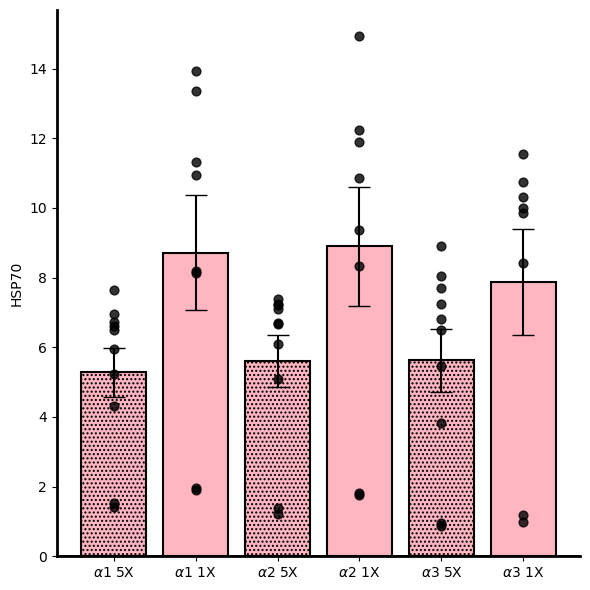

In [12]:
plot_bars_with_sem3([
                    hsp_a1_5x_all,
                     hsp_a1_1x_all,
                     hsp_a2_5x_all,
                     hsp_a2_1x_all,
                     hsp_a3_5x_all,
                     hsp_a3_1x_all,
                     
                     ],
                    labels = [
                      r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="HSP70", figsize=(6,6),
                       bar_color=["lightpink"], dot_color="black", spine_width=2, pattern = ['....', ''])

group: $\alpha$1 5X, mean: 1.5508262587918142, sem: 0.10069066037353216
group: $\alpha$1 1X, mean: 1.4870584594376237, sem: 0.1608037346992739
group: $\alpha$2 5X, mean: 1.4210172154786442, sem: 0.09419813015153013
group: $\alpha$2 1X, mean: 1.3512788745911037, sem: 0.14598949395718508
group: $\alpha$3 5X, mean: 1.171963162075089, sem: 0.11471345901664098
group: $\alpha$3 1X, mean: 1.2055501451677504, sem: 0.17263197021615764


<Axes: ylabel='mito'>

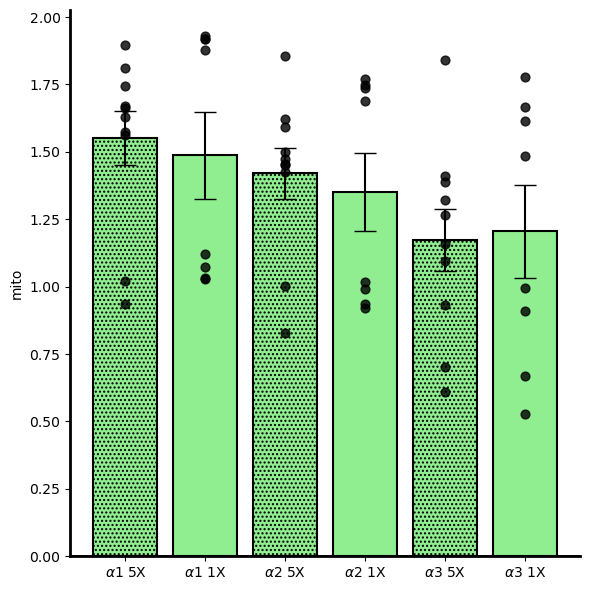

In [13]:
plot_bars_with_sem3([
                    mito_a1_5x_all,
                     mito_a1_1x_all,
                     mito_a2_5x_all,
                     mito_a2_1x_all,
                     mito_a3_5x_all,
                     mito_a3_1x_all,
                     
                     ],
                    labels = [
                   r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="mito", figsize=(6,6),
                       bar_color=["lightgreen"], dot_color="black", spine_width=2, pattern = ['....', ''])

group: $\alpha$1 5X, mean: 1.0, sem: 0.0
group: $\alpha$1 1X, mean: 1.0, sem: 0.0
group: $\alpha$2 5X, mean: 1.0, sem: 0.0
group: $\alpha$2 1X, mean: 1.0, sem: 0.0
group: $\alpha$3 5X, mean: 1.0, sem: 0.0
group: $\alpha$3 1X, mean: 1.0, sem: 0.0


<Axes: ylabel='BRP'>

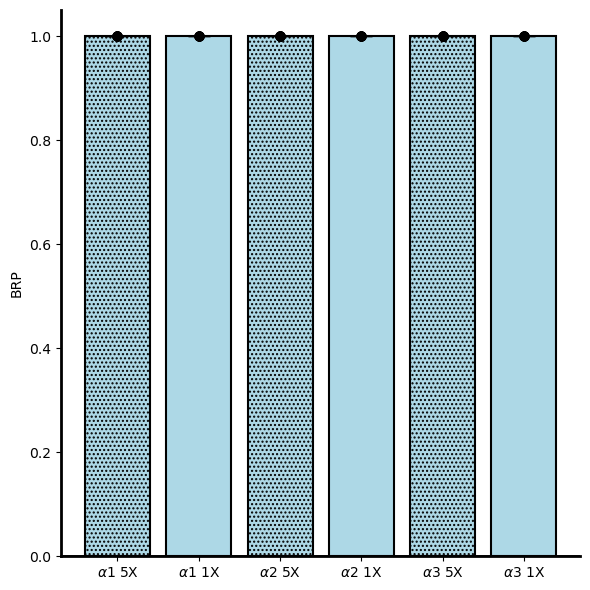

In [14]:
plot_bars_with_sem3([
                    brp_a1_5x_all,
                     brp_a1_1x_all,
                     brp_a2_5x_all,
                     brp_a2_1x_all,
                     brp_a3_5x_all,
                     brp_a3_1x_all,
                     
                     ],
                    labels = [
                    r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="BRP", figsize=(6,6),
                       bar_color=["lightblue"], dot_color="black", spine_width=2, pattern = ['....', ''])